# Faza 5: Razložljivost modela z metodo SHAP

**Zastavljen cilj**: Omogočiti popolno transparentnost in razumljivost črne skrinjice XGBoost modela preko globalnih in lokalnih SHAP (SHapley Additive exPlanations) vplivov.

Ker je XGBoost visoko-dimenzionalen drevesni model, so njegove notranje odločitve kompleksne. S pomočjo metode SHAP smo analizirali, kako so posamezne spremenljivke vplivale na modelovo napoved - tako na nivoju celotne baze kot tudi na nivoju specifičnih, tipičnih strank, s čimer si v bančništvu zagotovimo legitimnost odločanja.

## 1. Priprava in naložitev zmagovalnega modela

Pred razlago smo morali ponovno vzpostaviti okolje - naložiti testne podatke in naložiti predhodno izvožen `.pkl` XGBoost model.

In [10]:
import shap
import pandas as pd
import joblib

# Nalaganje poskusnih podatkov
train = pd.read_csv('../data/train_final.csv')
target_col = [col for col in train.columns if 'loan_status' in col.lower()][0]

X_train_dependent = train.drop(columns=[target_col])

# Bančni atributi za ločevanje
bank_features = [col for col in train.columns if any(x in col.lower() for x in ['fico', 'grade', 'int_rate'])]

# Množica brez bančnih ocen
X_train_indep = train.drop(columns=[target_col] + bank_features)

# Nalaganje obeh modelov
model_dependent = joblib.load('../models/xgb_model.pkl')            # Z banko
model_independent = joblib.load('../models/xgb_independent_model.pkl') # Brez banke

print("Podatki pripravljeni. Modela naložena.")

Podatki pripravljeni. Modela naložena.


## 2. Globalna razložljivost (Analiza celotne populacije)

Da bi razumeli globalno obnašanje modela, smo preverili, katere značilke prispevajo k najvišji oceni tveganja v testnem okolju. Prav tako smo prikazali združen porazdelitveni graf (`beeswarm`), ki lepo nakazuje ali visoke vrednosti določenega atributa korelirajo s povišanim (pozitivnim) tveganjem.

In [ ]:
from sklearn.cluster import KMeans

najboljsi_k = 3
final_kmeans = KMeans(n_clusters=najboljsi_k, random_state=42)
X_train_dependent['risk_cluster'] = final_kmeans.fit_predict(X_train_dependent)

# Ustvarimo SHAP explainerja za vsak model posebej
explainer_dep = shap.TreeExplainer(model_dependent)
explainer_indep = shap.TreeExplainer(model_independent)

# Vzamemo iste stranke
X_sample_dep = X_train_dependent.sample(n=500, random_state=42)
X_sample_indep = X_train_indep.sample(n=500, random_state=42)

X_sample_dep = X_sample_dep[model_dependent.feature_names_in_]
X_sample_indep = X_sample_indep[model_independent.feature_names_in_]

# Izračun SHAP vrednosti
shap_values_dep = explainer_dep(X_sample_dep)
shap_values_indep = explainer_indep(X_sample_indep)

print("SHAP vrednosti izračunane za oba modela.")

SHAP vrednosti izračunane za oba modela.


## 3. Lokalna razložljivost (Interpretacija specifičnih strank)

Globalna analiza potrjuje zanesljivost prijemov modela, nas pa zanima tudi "Zakaj točno smo zavrnili to stranko?" ali "Zakaj je tej posojilo odobreno?"

Poiskali in uvrstili smo en tipičen primer z zanesljivo profilom poplačila (npr. verjetnost neplačila ~0.05) ter in en tipičen primer z izjemno visokim tveganjem (npr. verjetnost > 0.85). Z uporabo `waterfall` grafa smo utemeljili prispevek vsake značilke pri teh dveh posameznikih.

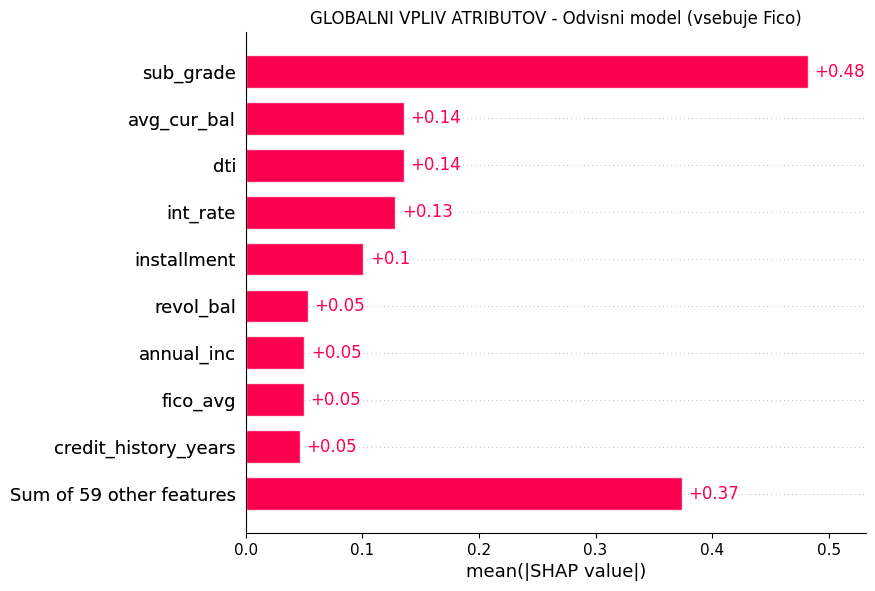

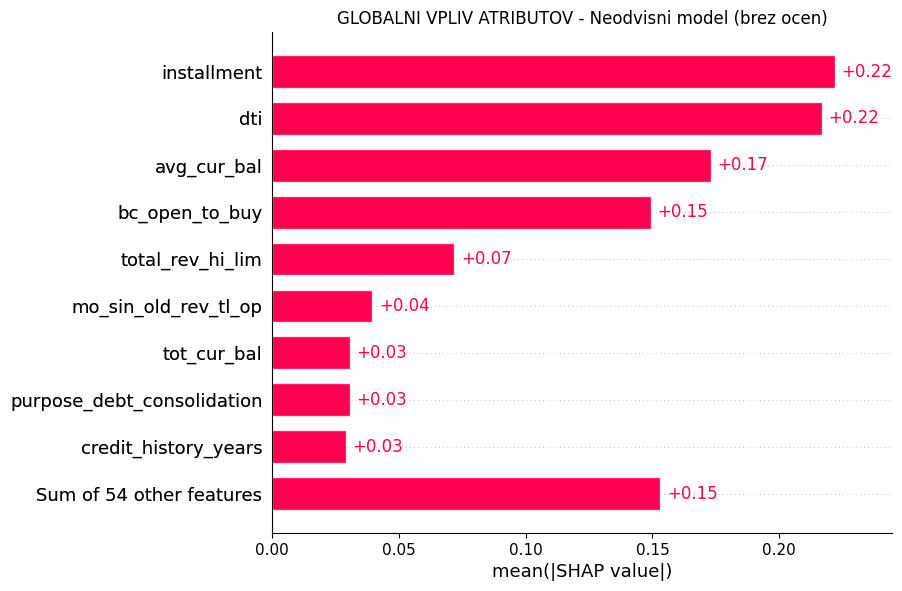

In [12]:
import matplotlib.pyplot as plt

# Prikaz globalnega vpliva za odvisni model (Z Fico ocenami)
plt.title("GLOBALNI VPLIV ATRIBUTOV - Odvisni model (vsebuje Fico)")
shap.plots.bar(shap_values_dep, max_display=10, show=False)
plt.show()

# Prikaz globalnega vpliva za neodvisni model
plt.title("GLOBALNI VPLIV ATRIBUTOV - Neodvisni model (brez ocen)")
shap.plots.bar(shap_values_indep, max_display=10, show=False)
plt.show()

## 4. Razvoj interaktivne aplikacije (Streamlit)

Za končno uporabo s strani bančnih referentov smo ustvarili interaktivno spletno aplikacijo. Aplikacija omogoča uporabniku dinamičen vnos lastnosti posojilojemalca in takojšen prikaz verjetnosti neplačila (default probability) ter SHAP razlage te odločitve. 
Kodo aplikacije razvijamo v ločeni python datoteki, od koder se neposredno zažene lokalni strežnik.

== RAZLAGA ZA STRANKO A: ODVISNI MODEL (Gleda Fico ocene) ==


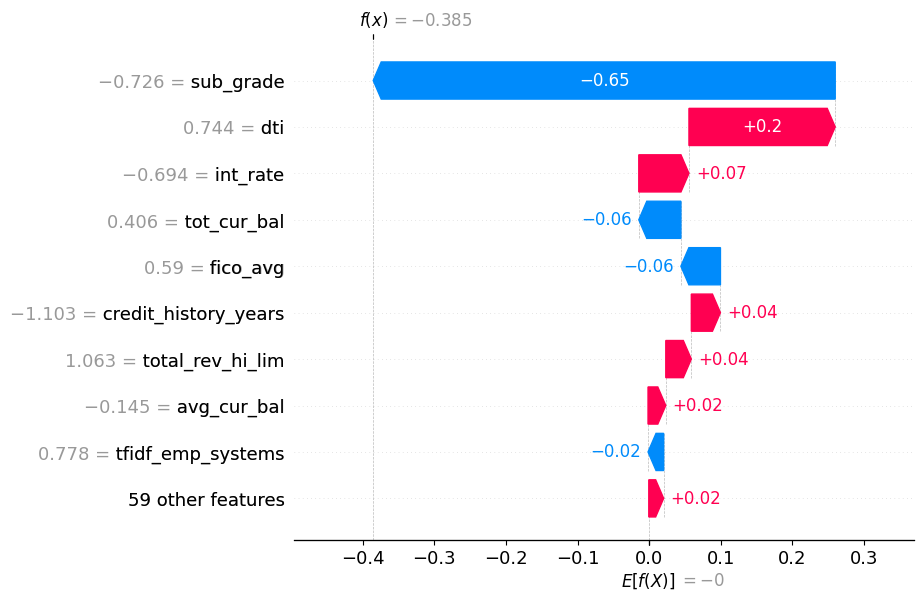

== RAZLAGA ZA STRANKO A: NEODVISNI MODEL ==


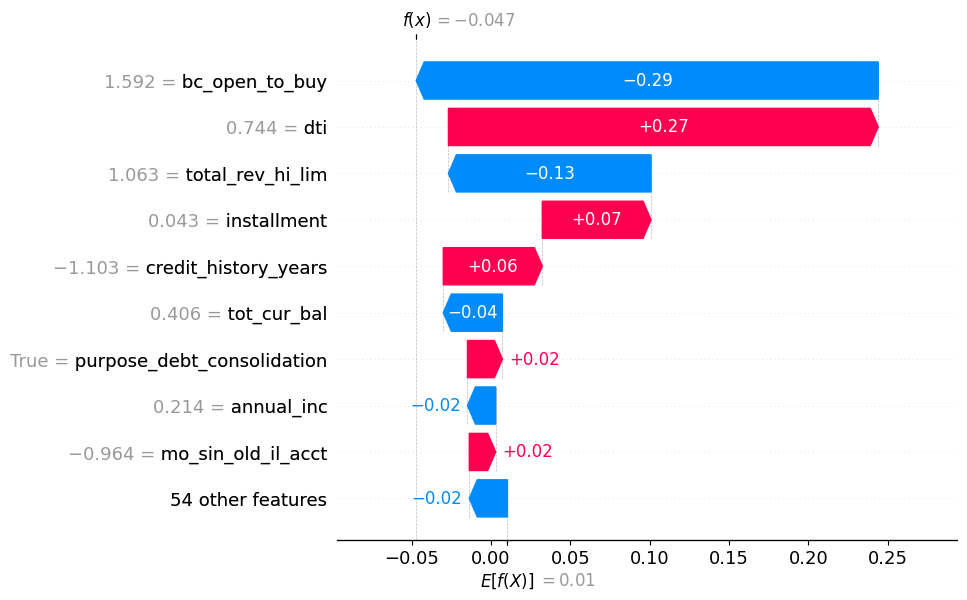

In [ ]:
INDEX_STRANKE = 0

print("== RAZLAGA ZA STRANKO A: ODVISNI MODEL (Gleda Fico ocene) ==")
shap.waterfall_plot(shap_values_dep[INDEX_STRANKE])

print("== RAZLAGA ZA STRANKO A: NEODVISNI MODEL ==")
shap.waterfall_plot(shap_values_indep[INDEX_STRANKE])

### Kako brati Waterfall graf (Interpretacija barv)
Pri vizualizaciji napovedovanja **Tveganja (Default = 1)**, posamezne barve na SHAP grafu pomenijo naslednje:

* 🔴 **Rdeča (+) puščica:** Dejavnik poveča tveganje. Katerikoli atribut obarvan rdeče (npr. visok *DTI* ali prisotnost *določenih NLP ključnih besed*), "potiska" končno odločitev višje proti enici (neplačilu). Deluje kot **alarm oziroma dejavnik tveganja**.
* 🔵 **Modra (-) puščica:** Dejavnik zmanjša tveganje. Atribut, obarvan modro (npr. odličen *sub_grade* ali *visok letni dohodek*), "potiska" model v nasprotno stran, proti ničli (varnemu poplačilu kredita). Deluje kot **zaščitni dejavnik**, ki pomiri model.

Ko model sešteje osnovno oceno ter vse rdeče in modre vplive, dobi končno verjetnost, na podlagi katere kredit zavrne ali odobri.